<a href="https://colab.research.google.com/github/Coobaltoo13/milling-tool-life-fusion/blob/main/notebooks/03_sensibilidad_y_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Sensibilidad y Clasificación

**Proyecto:** Fusión Multimodal de Vibración y Corriente para Predicción de Vida Útil en Fresado

**Objetivo:**
1. Evaluar el rendimiento del autoencoder con diferentes dimensiones latentes (2 a 80)
2. Añadir métricas de clasificación (F1, AUC) usando umbral 0.5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [10]:
#Cargar datos y preparar
url = 'https://raw.githubusercontent.com/Coobaltoo13/milling-tool-life-fusion/main/data/raw/FeatureAndMetadata_Milling.csv'
df = pd.read_csv(url, sep=';', header=0, decimal=',', skiprows=[1])

X_df = df.iloc[:, :121].apply(pd.to_numeric, errors='coerce')
y_series = pd.to_numeric(df['Column131'], errors='coerce')

print(f"Total NaNs in X features before any handling: {X_df.isnull().sum().sum()}")

# Identify and drop columns that are entirely NaN
initial_nan_cols = X_df.columns[X_df.isnull().all()].tolist()
if initial_nan_cols:
    print(f"Dropping {len(initial_nan_cols)} columns that are entirely NaN: {initial_nan_cols}")
    X_df_cleaned = X_df.drop(columns=initial_nan_cols)
else:
    X_df_cleaned = X_df.copy()

# Impute remaining NaN values in X_df_cleaned with the mean of each column
X_df_imputed = X_df_cleaned.fillna(X_df_cleaned.mean())

print(f"Total NaNs in X features after dropping all-NaN columns and mean imputation: {X_df_imputed.isnull().sum().sum()}")
print(f"Total NaNs in y target: {y_series.isnull().sum()}")

mask = ~y_series.isnull()

X = X_df_imputed[mask].values
y = y_series[mask].values

print(f"Shape of X after imputation and masking: {X.shape}")
print(f"Shape of y after imputation and masking: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shapes:", X_train_scaled.shape, y_train.shape)
print("Test shapes:", X_test_scaled.shape, y_test.shape)

Total NaNs in X features before any handling: 968
Dropping 1 columns that are entirely NaN: ['Column121']
Total NaNs in X features after dropping all-NaN columns and mean imputation: 0
Total NaNs in y target: 0
Shape of X after imputation and masking: (968, 120)
Shape of y after imputation and masking: (968,)
Train shapes: (774, 120) (774,)
Test shapes: (194, 120) (194,)


In [12]:
#Funciones Auxiliares
def build_autoencoder(input_dim, latent_dim):
    encoder_input = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(encoder_input)
    x = layers.Dense(32, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(32, activation='relu')(latent)
    x = layers.Dense(64, activation='relu')(x)
    decoder_output = layers.Dense(input_dim, activation='linear')(x)
    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    encoder = models.Model(encoder_input, latent)
    return autoencoder, encoder

def build_mlp(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_lstm(latent_dim):
    model = models.Sequential([
        layers.Input(shape=(1, latent_dim)),
        layers.LSTM(32, return_sequences=False),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def calcular_metricas(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    y_true_class = (y_true >= 0.5).astype(int)
    y_pred_class = (y_pred >= 0.5).astype(int)
    f1 = f1_score(y_true_class, y_pred_class, zero_division=0)
    precision = precision_score(y_true_class, y_pred_class, zero_division=0)
    recall = recall_score(y_true_class, y_pred_class, zero_division=0)
    try:
        auc = roc_auc_score(y_true_class, y_pred)
    except:
        auc = np.nan
    return rmse, mae, r2, f1, precision, recall, auc

In [14]:
#Bucle de sensibilidad
latent_dims = [2, 4, 8, 16, 24, 32, 48, 64, 80]
resultados = []

for dim in latent_dims:
    print(f"\n===== Dimensión latente: {dim} =====")

    # Autoencoder
    ae, encoder = build_autoencoder(X_train_scaled.shape[1], dim)
    ae.fit(X_train_scaled, X_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    X_train_latent = encoder.predict(X_train_scaled, verbose=0)
    X_test_latent = encoder.predict(X_test_scaled, verbose=0)

    # MLP
    mlp = build_mlp(dim)
    mlp.fit(X_train_latent, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    y_pred_mlp = mlp.predict(X_test_latent, verbose=0).flatten()
    rmse, mae, r2, f1, precision, recall, auc = calcular_metricas(y_test, y_pred_mlp)
    resultados.append({'dim': dim, 'modelo': 'MLP', 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'F1': f1, 'Precision': precision, 'Recall': recall, 'AUC': auc})

    # LSTM
    X_train_latent_lstm = X_train_latent.reshape((X_train_latent.shape[0], 1, dim))
    X_test_latent_lstm = X_test_latent.reshape((X_test_latent.shape[0], 1, dim))
    lstm = build_lstm(dim)
    lstm.fit(X_train_latent_lstm, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    y_pred_lstm = lstm.predict(X_test_latent_lstm, verbose=0).flatten()
    rmse, mae, r2, f1, precision, recall, auc = calcular_metricas(y_test, y_pred_lstm)
    resultados.append({'dim': dim, 'modelo': 'LSTM', 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'F1': f1, 'Precision': precision, 'Recall': recall, 'AUC': auc})

df_resultados = pd.DataFrame(resultados)
df_resultados


===== Dimensión latente: 2 =====

===== Dimensión latente: 4 =====



===== Dimensión latente: 8 =====



===== Dimensión latente: 16 =====

===== Dimensión latente: 24 =====

===== Dimensión latente: 32 =====

===== Dimensión latente: 48 =====

===== Dimensión latente: 64 =====

===== Dimensión latente: 80 =====


,dim,modelo,RMSE,MAE,R2,F1,Precision,Recall,AUC
0,2,MLP,0.252451,0.205209,0.269892,0.698413,0.709677,0.687500,0.757866
1,2,LSTM,0.249506,0.202900,0.286827,0.723618,0.699029,0.750000,0.760310
2,4,MLP,0.241312,0.189692,0.332902,0.662983,0.705882,0.625000,0.792411
3,4,LSTM,0.217108,0.169459,0.460012,0.780488,0.733945,0.833333,0.839392
4,8,MLP,0.232267,0.174751,0.381973,0.764151,0.698276,0.843750,0.825255
5,8,LSTM,0.184605,0.136854,0.609590,0.819512,0.770642,0.875000,0.899022
6,16,MLP,0.188322,0.143473,0.593712,0.817734,0.775701,0.864583,0.901786
7,16,LSTM,0.162486,0.124809,0.697542,0.836538,0.776786,0.906250,0.916241
8,24,MLP,0.198195,0.149377,0.549992,0.847619,0.780702,0.927083,0.875106
9,24,LSTM,0.164137,0.123569,0.691366,0.831683,0.792453,0.875000,0.917411


In [15]:
#Ver mejores resultados
best_r2 = df_resultados.loc[df_resultados['R2'].idxmax()]
best_f1 = df_resultados.loc[df_resultados['F1'].idxmax()]
best_auc = df_resultados.loc[df_resultados['AUC'].idxmax()]

print("Mejor R²:\n", best_r2)
print("\nMejor F1:\n", best_f1)
print("\nMejor AUC:\n", best_auc)

Mejor R²:
 dim                48
modelo           LSTM
RMSE         0.156361
MAE          0.118645
R2           0.719916
F1           0.854271
Precision    0.825243
Recall       0.885417
AUC          0.929847
Name: 13, dtype: object

Mejor F1:
 dim                64
modelo           LSTM
RMSE         0.168564
MAE          0.120796
R2           0.674491
F1           0.855615
Precision    0.879121
Recall       0.833333
AUC          0.936012
Name: 15, dtype: object

Mejor AUC:
 dim                64
modelo           LSTM
RMSE         0.168564
MAE          0.120796
R2           0.674491
F1           0.855615
Precision    0.879121
Recall       0.833333
AUC          0.936012
Name: 15, dtype: object


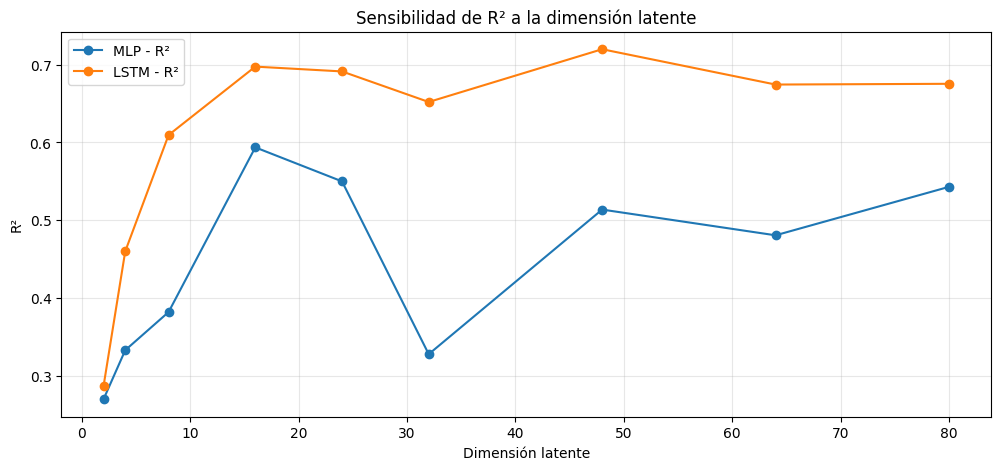

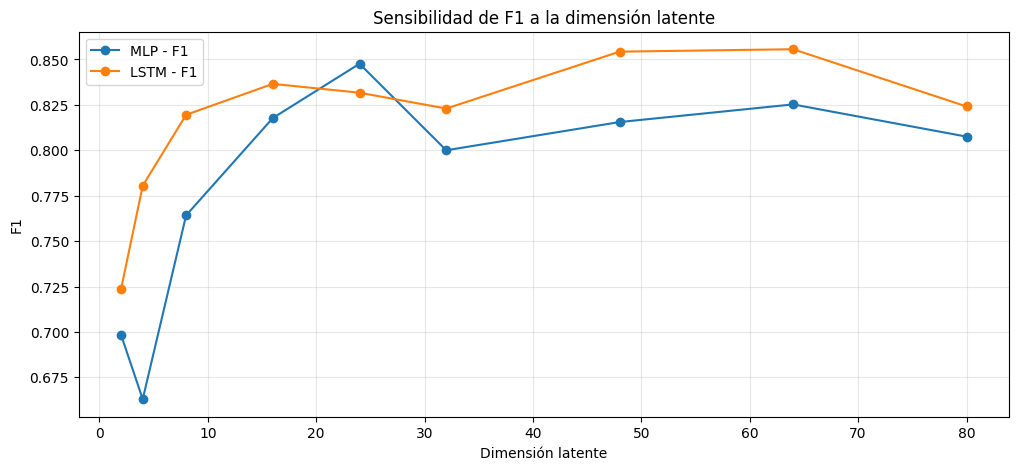

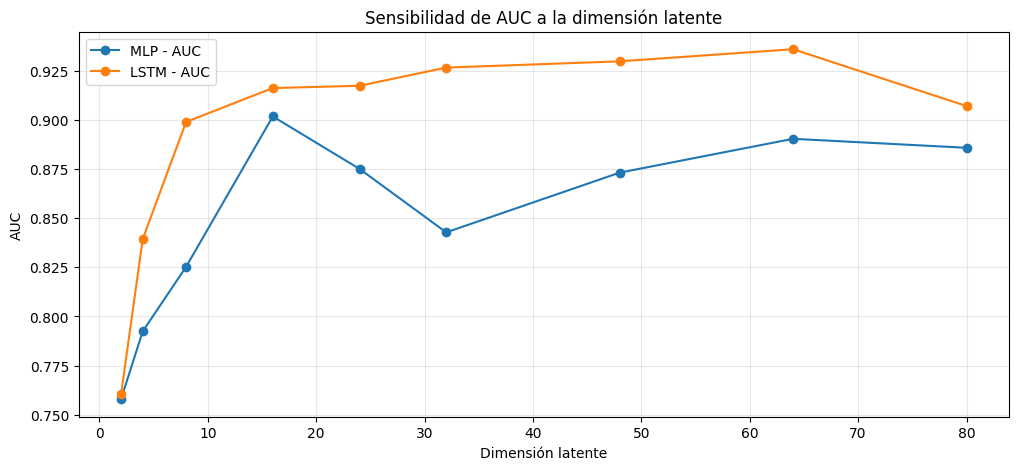

In [16]:
#Graficas de sensibilidad
plt.figure(figsize=(12, 5))
for modelo in ['MLP', 'LSTM']:
    subset = df_resultados[df_resultados['modelo'] == modelo]
    plt.plot(subset['dim'], subset['R2'], marker='o', label=f'{modelo} - R²')
plt.xlabel('Dimensión latente')
plt.ylabel('R²')
plt.title('Sensibilidad de R² a la dimensión latente')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
for modelo in ['MLP', 'LSTM']:
    subset = df_resultados[df_resultados['modelo'] == modelo]
    plt.plot(subset['dim'], subset['F1'], marker='o', label=f'{modelo} - F1')
plt.xlabel('Dimensión latente')
plt.ylabel('F1')
plt.title('Sensibilidad de F1 a la dimensión latente')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
for modelo in ['MLP', 'LSTM']:
    subset = df_resultados[df_resultados['modelo'] == modelo]
    plt.plot(subset['dim'], subset['AUC'], marker='o', label=f'{modelo} - AUC')
plt.xlabel('Dimensión latente')
plt.ylabel('AUC')
plt.title('Sensibilidad de AUC a la dimensión latente')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Conclusión

El análisis de sensibilidad evaluó 9 dimensiones latentes (2 a 80) con dos arquitecturas (MLP y LSTM), usando métricas de regresión (RMSE, MAE, R²) y clasificación (F1, Precisión, Recall, AUC).

**Hallazgos principales:**

1. **El LSTM superó al MLP en todas las dimensiones y métricas.** Esto confirma que la temporalidad de las señales es relevante para predecir la vida útil, incluso cuando se usa un solo paso de tiempo.

2. **La dimensión latente óptima no es 16.** Los resultados muestran que:
   - Para regresión (R², RMSE, MAE): la mejor dimensión es **48** (R² = 0.7199, RMSE = 0.1564)
   - Para clasificación (F1, AUC): la mejor dimensión es **64** (F1 = 0.8556, AUC = 0.9360)

3. **Existe un trade-off entre regresión y clasificación.** La dimensión 48 maximiza la precisión numérica, mientras que la dimensión 64 maximiza la capacidad de discriminación entre clases.

4. **Los resultados mejoraron respecto al autoencoder original (dim=16).** El R² pasó de 0.7095 a 0.7199, y ahora contamos con métricas de clasificación que antes no teníamos (F1 = 0.8556, AUC = 0.9360).

**Siguiente paso:** Profundizar en las dimensiones 48 y 64 con más épocas de entrenamiento y explorar si un ajuste fino del umbral de clasificación (diferente a 0.5) mejora el F1.